# Muon Shaping FastVersion Points

Read all muon ROOT files from CONF6, compute shaping key points with `Shaping_FastVersion.hh`, and compare hit-level energy/time with fast peak, slow peak, slow sample, and trigger time.


In [1]:
from pathlib import Path
import importlib
import re
import subprocess
import sys
import sysconfig
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.ticker import ScalarFormatter

DIGITIZATION_DIR = Path('/home/llr/ilc/shi/code/TB_2026_6/Digitization')
DATA_DIR = Path('/home/llr/ilc/shi/data/SiWECAL-Prototype/TB2026-06/CONF6/mu-/MC')
STYLE_PATH = Path('/home/llr/ilc/shi/code/Plot_style/cepc.mplstyle')

HIT_COLLECTION_NAME = 'simplecaloRO'
MAX_FILES = None
MAX_EVENTS_PER_FILE = None
RANDOM_SEED_BASE = 5489
SAVE_CSV = False
OUTPUT_CSV = DIGITIZATION_DIR / 'MuonShapingFastVersion_points.csv'

CELL_SHAPING_CFG = {
    'mip_value_mev': 0.1472,
    'mip_threshold': 0.5,
    'delay_ns': 160.0,
    'tau_fast_ns': 30.0,
    'tau_slow_ns': 180.0,
    'order_fast': 2,
    'order_slow': 2,
    'fast_window_ns': 200.0,
    'slow_window_ns': 500.0,
    'fast_noise': 1 / 30.,
    'slow_noise': 1 / 12.,
    'peak_search_bins': 64,
    'refine_iterations': 48,
    'trigger_search_bins': 64,
}

if STYLE_PATH.exists():
    plt.style.use(str(STYLE_PATH))

for lib_name in ('libDDG4Plugins', 'libDDG4IO', 'libDDG4'):
    ROOT.gSystem.Load(lib_name)


def natural_key(path):
    return [int(part) if part.isdigit() else part for part in re.split(r'(\d+)', path.name)]


root_files = sorted(DATA_DIR.glob('*.root'), key=natural_key)
if MAX_FILES is not None:
    root_files = root_files[:MAX_FILES]
if not root_files:
    raise FileNotFoundError(f'No ROOT files found in {DATA_DIR}')

print(f'Data directory: {DATA_DIR}')
print(f'ROOT files selected: {len(root_files)}')
print(f'MAX_EVENTS_PER_FILE: {MAX_EVENTS_PER_FILE}')


Warning in <TClassTable::Add>: class _Rb_tree_iterator<pair<const int,dd4hep::sim::Geant4Particle*> > already in TClassTable
Warning in <TClassTable::Add>: class _Rb_tree_const_iterator<pair<const int,dd4hep::sim::Geant4Particle*> > already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::SimpleRun already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::SimpleEvent already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::DataExtension already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4HitData already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4HitData::MonteCarloContrib already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4Tracker already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4Tracker::Hit already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4Calorimeter already in TClassTable
Warning in <TClassTable::A

Data directory: /home/llr/ilc/shi/data/SiWECAL-Prototype/TB2026-06/CONF6/mu-/MC
ROOT files selected: 50
MAX_EVENTS_PER_FILE: None


## Build and Import C++ Shaping Module

The notebook imports the CMake/pybind11 module built from `Shaping_FastVersion.hh`. The build directory is tied to the active Python version so it matches the notebook kernel ABI.


In [2]:
PY_MODULE_BUILD_DIR = DIGITIZATION_DIR / f'build_py{sys.version_info.major}{sys.version_info.minor}'
PY_MODULE_DIR = PY_MODULE_BUILD_DIR / 'python'


def ensure_cell_shaping_cpp():
    ext_suffix = sysconfig.get_config_var('EXT_SUFFIX') or '.so'
    module_path = PY_MODULE_DIR / f'cell_shaping_cpp{ext_suffix}'
    if not module_path.exists():
        subprocess.run(
            ['cmake', '-S', str(DIGITIZATION_DIR), '-B', str(PY_MODULE_BUILD_DIR), f'-DPython3_EXECUTABLE={sys.executable}'],
            check=True,
        )
        subprocess.run(
            ['cmake', '--build', str(PY_MODULE_BUILD_DIR), '--target', 'cell_shaping_cpp'],
            check=True,
        )
    if str(PY_MODULE_DIR) not in sys.path:
        sys.path.insert(0, str(PY_MODULE_DIR))
    return importlib.import_module('cell_shaping_cpp')


cell_shaping_cpp = ensure_cell_shaping_cpp()
print(f'Imported {cell_shaping_cpp.__name__} from {cell_shaping_cpp.__file__}')


Imported cell_shaping_cpp from /home/llr/ilc/shi/code/TB_2026_6/Digitization/build_py313/python/cell_shaping_cpp.cpython-313-x86_64-linux-gnu.so


## Configure Shaping FastVersion


In [3]:
def make_cpp_cfg(cfg_dict):
    cfg = cell_shaping_cpp.CellShapingConfig()
    cfg.mip_value_gev = cfg_dict['mip_value_mev'] * 1.0e-3
    cfg.mip_threshold = cfg_dict['mip_threshold']
    cfg.delay_ns = cfg_dict['delay_ns']
    cfg.tau_fast_ns = cfg_dict['tau_fast_ns']
    cfg.tau_slow_ns = cfg_dict['tau_slow_ns']
    cfg.order_fast = cfg_dict['order_fast']
    cfg.order_slow = cfg_dict['order_slow']
    cfg.fast_window_ns = cfg_dict['fast_window_ns']
    cfg.slow_window_ns = cfg_dict['slow_window_ns']
    cfg.fast_noise_mip = cfg_dict['fast_noise']
    cfg.slow_noise_mip = cfg_dict['slow_noise']
    cfg.peak_search_bins = cfg_dict['peak_search_bins']
    cfg.refine_iterations = cfg_dict['refine_iterations']
    cfg.trigger_search_bins = cfg_dict['trigger_search_bins']
    return cfg


cpp_cfg = make_cpp_cfg(CELL_SHAPING_CFG)
print(f'MIP value: {CELL_SHAPING_CFG["mip_value_mev"]} MeV/MIP')
print(f'Threshold: {CELL_SHAPING_CFG["mip_threshold"]} MIP')


MIP value: 0.1472 MeV/MIP
Threshold: 0.5 MIP


## Read Hits and Steps

For each hit, step information follows the same relation as `CellShapingDemo.ipynb`: `hit.truth` stores step-level energy deposits and times for that hit. The hit time here is defined as the minimum positive finite step time in the hit.


In [4]:
def step_arrays_for_hit(hit):
    step_energy = []
    step_time = []
    step_track_id = []
    step_pdg_id = []

    for j in range(hit.truth.size()):
        contrib = hit.truth.at(j)
        step_energy.append(float(contrib.deposit))
        step_time.append(float(contrib.time))
        step_track_id.append(int(contrib.trackID))
        step_pdg_id.append(int(contrib.pdgID))

    step_energy = np.asarray(step_energy, dtype=np.float64)
    step_time = np.asarray(step_time, dtype=np.float64)
    step_track_id = np.asarray(step_track_id, dtype=np.int64)
    step_pdg_id = np.asarray(step_pdg_id, dtype=np.int64)
    good = np.isfinite(step_energy) & np.isfinite(step_time) & (step_energy > 0.0)
    return step_energy[good], step_time[good], step_track_id[good], step_pdg_id[good]


def point_value(points, point_name, value_name):
    return float(points[point_name][value_name])


def process_hit(hit, file_index, file_name, event_index, hit_index):
    step_energy_mev, step_time_ns, step_track_id, step_pdg_id = step_arrays_for_hit(hit)
    n_steps = int(len(step_energy_mev))
    hit_time_ns = float(np.min(step_time_ns)) if n_steps else np.nan
    seed = RANDOM_SEED_BASE + file_index * 1_000_000 + event_index * 10_000 + hit_index

    if n_steps:
        points = cell_shaping_cpp.shaping_fast_version(
            (step_energy_mev * 1.0e-3).astype(np.float64).tolist(),
            step_time_ns.astype(np.float64).tolist(),
            cpp_cfg,
            seed=int(seed),
        )
        fast_peak_time_ns = point_value(points, 'fast_peak', 'time_ns')
        fast_peak_mip = point_value(points, 'fast_peak', 'signal_mip')
        slow_peak_time_ns = point_value(points, 'slow_peak', 'time_ns')
        slow_peak_mip = point_value(points, 'slow_peak', 'signal_mip')
        trigger_time_ns = point_value(points, 'trigger', 'time_ns')
        slow_sample_time_ns = point_value(points, 'slow_sample', 'time_ns')
        slow_sample_mip = point_value(points, 'slow_sample', 'signal_mip')
    else:
        fast_peak_time_ns = fast_peak_mip = np.nan
        slow_peak_time_ns = slow_peak_mip = np.nan
        trigger_time_ns = slow_sample_time_ns = slow_sample_mip = np.nan

    hit_energy_mev = float(hit.energyDeposit)
    return {
        'file_index': int(file_index),
        'file_name': file_name,
        'event_index': int(event_index),
        'hit_index': int(hit_index),
        'cell_id': int(hit.cellID),
        'hit_energy_mev': hit_energy_mev,
        'hit_energy_mip': hit_energy_mev / CELL_SHAPING_CFG['mip_value_mev'],
        'hit_time_ns': hit_time_ns,
        'step_number': n_steps,
        'step_energy_sum_mev': float(np.sum(step_energy_mev)) if n_steps else 0.0,
        'fast_peak_time_ns': fast_peak_time_ns,
        'fast_peak_mip': fast_peak_mip,
        'slow_peak_time_ns': slow_peak_time_ns,
        'slow_peak_mip': slow_peak_mip,
        'trigger_time_ns': trigger_time_ns,
        'slow_sample_time_ns': slow_sample_time_ns,
        'slow_sample_mip': slow_sample_mip,
    }


## Process All Muon ROOT Files


In [5]:
rows = []
file_summaries = []

for file_index, root_path in enumerate(root_files):
    root_file = ROOT.TFile.Open(str(root_path))
    if not root_file or root_file.IsZombie():
        print(f'Skip unreadable file: {root_path}')
        continue

    tree = root_file.Get('EVENT')
    if not tree:
        root_file.Close()
        print(f'Skip file without EVENT tree: {root_path}')
        continue

    n_events = int(tree.GetEntries())
    if MAX_EVENTS_PER_FILE is not None:
        n_events = min(n_events, int(MAX_EVENTS_PER_FILE))

    n_hits_file = 0
    for event_index in range(n_events):
        tree.GetEntry(event_index)
        hits = getattr(tree, HIT_COLLECTION_NAME)
        n_hits = int(hits.size())
        n_hits_file += n_hits
        for hit_index in range(n_hits):
            rows.append(process_hit(hits.at(hit_index), file_index, root_path.name, event_index, hit_index))

    root_file.Close()
    file_summaries.append({'file_index': file_index, 'file_name': root_path.name, 'events': n_events, 'hits': n_hits_file})
    print(f'[{file_index + 1}/{len(root_files)}] {root_path.name}: events={n_events}, hits={n_hits_file}, total_rows={len(rows)}')

points_df = pd.DataFrame(rows)
file_summary_df = pd.DataFrame(file_summaries)

if SAVE_CSV:
    points_df.to_csv(OUTPUT_CSV, index=False)
    print(f'Saved {OUTPUT_CSV}')

print(f'Total hits processed: {len(points_df)}')
display(file_summary_df.head())
display(points_df.head())


[1/50] 100GeV_1.root: events=200, hits=3615, total_rows=3615
[2/50] 100GeV_2.root: events=200, hits=3819, total_rows=7434
[3/50] 100GeV_3.root: events=200, hits=3744, total_rows=11178
[4/50] 100GeV_4.root: events=200, hits=3651, total_rows=14829
[5/50] 100GeV_5.root: events=200, hits=3376, total_rows=18205
[6/50] 100GeV_6.root: events=200, hits=3582, total_rows=21787
[7/50] 100GeV_7.root: events=200, hits=3595, total_rows=25382
[8/50] 100GeV_8.root: events=200, hits=3599, total_rows=28981
[9/50] 100GeV_9.root: events=200, hits=3524, total_rows=32505
[10/50] 100GeV_10.root: events=200, hits=3702, total_rows=36207
[11/50] 100GeV_11.root: events=200, hits=3521, total_rows=39728
[12/50] 100GeV_12.root: events=200, hits=4293, total_rows=44021
[13/50] 100GeV_13.root: events=200, hits=3869, total_rows=47890
[14/50] 100GeV_14.root: events=200, hits=3550, total_rows=51440
[15/50] 100GeV_15.root: events=200, hits=3717, total_rows=55157
[16/50] 100GeV_16.root: events=200, hits=4032, total_rows=59

,file_index,file_name,events,hits
0,0,100GeV_1.root,200,3615
1,1,100GeV_2.root,200,3819
2,2,100GeV_3.root,200,3744
3,3,100GeV_4.root,200,3651
4,4,100GeV_5.root,200,3376


,file_index,file_name,event_index,hit_index,cell_id,hit_energy_mev,hit_energy_mip,hit_time_ns,step_number,step_energy_sum_mev,fast_peak_time_ns,fast_peak_mip,slow_peak_time_ns,slow_peak_mip,trigger_time_ns,slow_sample_time_ns,slow_sample_mip
0,0,100GeV_1.root,0,0,170497,0.190966,1.297324,0.686809,38,0.190966,30.687477,1.381686,180.687475,1.421351,9.529117,169.529117,1.394383
1,0,100GeV_1.root,0,1,170498,0.137728,0.935654,0.714495,17,0.137728,30.715184,1.042279,180.715183,0.847217,12.015583,172.015583,1.010803
2,0,100GeV_1.root,0,2,170499,0.128711,0.874396,0.742181,14,0.128711,30.742811,0.988173,180.742811,0.875461,12.685188,172.685188,0.898458
3,0,100GeV_1.root,0,3,170500,0.147551,1.002386,0.769867,18,0.147551,30.770518,1.106480,180.770517,1.101577,11.472755,171.472755,1.060219
4,0,100GeV_1.root,0,4,170501,0.242345,1.646367,0.797552,28,0.242345,30.798346,1.752430,180.798345,1.813280,8.305495,168.305495,1.785216


## Summary and Quality Masks


In [6]:
finite_energy = np.isfinite(points_df['hit_energy_mip'])
valid_fast = finite_energy & np.isfinite(points_df['fast_peak_mip']) & (points_df['fast_peak_time_ns'] >= 0.0)
valid_slow = finite_energy & np.isfinite(points_df['slow_peak_mip']) & (points_df['slow_peak_time_ns'] >= 0.0)
valid_sample = finite_energy & np.isfinite(points_df['slow_sample_mip']) & (points_df['slow_sample_time_ns'] >= 0.0)
valid_trigger = np.isfinite(points_df['hit_time_ns']) & np.isfinite(points_df['trigger_time_ns']) & (points_df['trigger_time_ns'] >= 0.0)

summary = pd.DataFrame({
    'quantity': ['all hits', 'valid fast peak', 'valid slow peak', 'valid slow sample', 'valid trigger'],
    'count': [len(points_df), int(valid_fast.sum()), int(valid_slow.sum()), int(valid_sample.sum()), int(valid_trigger.sum())],
})
display(summary)

display(points_df[[
    'file_name', 'event_index', 'hit_index', 'cell_id', 'hit_energy_mip', 'hit_time_ns',
    'fast_peak_mip', 'slow_peak_mip', 'slow_sample_mip', 'trigger_time_ns', 'step_number'
]].describe(include='all'))


,quantity,count
0,all hits,183629
1,valid fast peak,178815
2,valid slow peak,178815
3,valid slow sample,178791
4,valid trigger,178791


,file_name,event_index,hit_index,cell_id,hit_energy_mip,hit_time_ns,fast_peak_mip,slow_peak_mip,slow_sample_mip,trigger_time_ns,step_number
count,183629,183629.000000,183629.000000,183629.000000,1.836290e+05,183629.000000,183629.000000,183629.000000,183629.000000,183629.000000,183629.000000
unique,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,100GeV_12.root,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,100.217760,13.892098,170467.131570,1.991156e+00,1.083081,2.148856,2.149157,2.134247,9.442835,44.172179
std,NaN,57.805553,31.161417,10398.147262,6.048431e+00,19.306965,6.550201,6.550824,6.469528,3.352503,136.111376
min,NaN,0.000000,0.000000,2566.000000,9.992332e-07,0.686809,-0.063726,-0.092060,0.000000,-1.000000,1.000000
25%,NaN,50.000000,4.000000,170499.000000,9.965430e-01,0.797552,1.078373,1.075385,1.071999,7.612298,18.000000
50%,NaN,100.000000,9.000000,170504.000000,1.156133e+00,0.912965,1.253796,1.265822,1.261170,10.352401,25.000000
75%,NaN,151.000000,13.000000,170509.000000,1.779353e+00,1.010033,1.925822,1.928989,1.917557,11.528879,42.000000


## Hit Energy and Shaping Amplitude Histograms


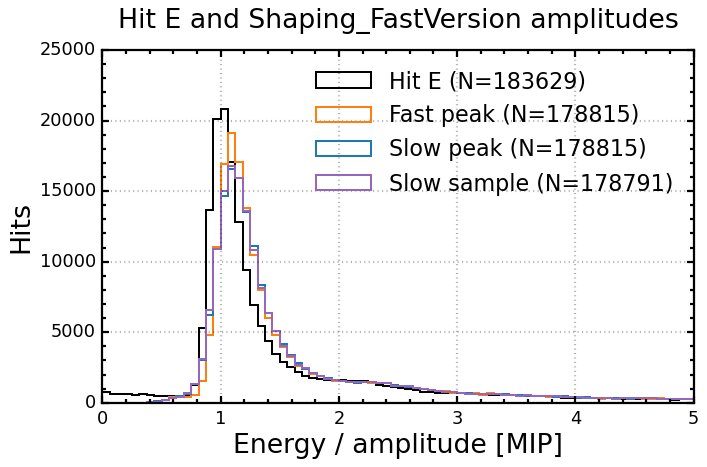

In [11]:
energy_hist_specs = [
    ('hit_energy_mip', finite_energy, 'Hit E', 'black'),
    ('fast_peak_mip', valid_fast, 'Fast peak', 'tab:orange'),
    ('slow_peak_mip', valid_slow, 'Slow peak', 'tab:blue'),
    ('slow_sample_mip', valid_sample, 'Slow sample', 'tab:purple'),
]

energy_values = []
for column, mask, _, _ in energy_hist_specs:
    values = points_df.loc[mask, column].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    if len(values):
        energy_values.append(values)

if not energy_values:
    print('No finite energy/amplitude values to plot.')
else:
    bins = np.linspace(0.0, 5.0, 81)

    fig, ax = plt.subplots(figsize=(9, 6))
    for column, mask, label, color in energy_hist_specs:
        values = points_df.loc[mask, column].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
        if len(values) == 0:
            continue
        ax.hist(values, bins=bins, histtype='step', linewidth=1.8, color=color, label=f'{label} (N={len(values)})')

    ax.set_xlim(0.0, 5.0)
    ax.set_xlabel('Energy / amplitude [MIP]')
    ax.set_ylabel('Hits')
    ax.set_title('Hit E and Shaping_FastVersion amplitudes')
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()


## Hit Time and Trigger Time Histograms


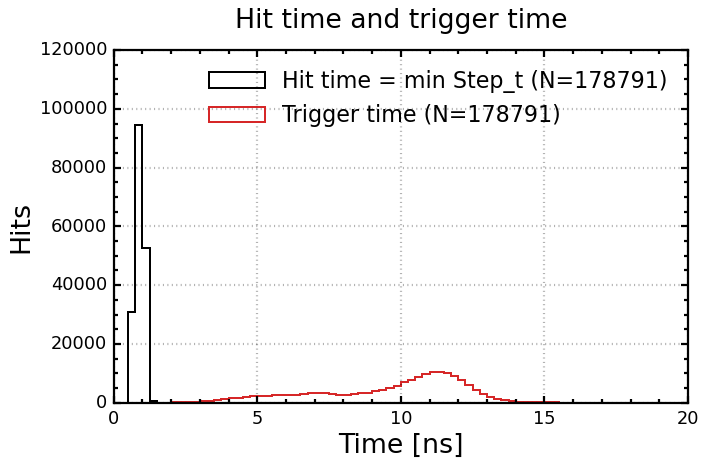

,hit_time_ns,trigger_time_ns
count,178791.000000,178791.000000
mean,0.915700,9.725413
std,1.171245,2.917640
min,0.686809,1.251720
25%,0.797552,7.939820
50%,0.912965,10.429613
75%,1.010033,11.556776
max,178.340312,184.008288


In [12]:
time_df = points_df.loc[valid_trigger].copy()

time_hist_specs = [
    ('hit_time_ns', 'Hit time = min Step_t', 'black'),
    ('trigger_time_ns', 'Trigger time', 'tab:red'),
]

time_values = []
for column, _, _ in time_hist_specs:
    values = time_df[column].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    if len(values):
        time_values.append(values)

if not time_values:
    print('No finite hit/trigger time values to plot.')
else:
    bins = np.linspace(0.0, 20.0, 81)

    fig, ax = plt.subplots(figsize=(9, 6))
    for column, label, color in time_hist_specs:
        values = time_df[column].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
        if len(values) == 0:
            continue
        ax.hist(values, bins=bins, histtype='step', linewidth=1.8, color=color, label=f'{label} (N={len(values)})')

    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlim(0.0, 20.0)
    ax.set_xlabel('Time [ns]')
    ax.set_ylabel('Hits')
    ax.set_title('Hit time and trigger time')
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

    display(time_df[['hit_time_ns', 'trigger_time_ns']].describe())
